# Clasificación multiclase con Regresión Logística One-vs-All

## Dataset 1: BRFSS 2020 Survey Data

**Estudiante:** Mancilla Rodriguez Ulises Jesus  
**Dataset:** Datos de la encuesta del Sistema de Vigilancia de Factores de Riesgo Conductuales de 2020  
**URL:** https://www.kaggle.com/datasets/aemreusta/brfss-2020-survey-data/data

El objetivo de este cuadernillo es entrenar un modelo de **clasificación multiclase** utilizando la estructura del cuadernillo guía de regresión logística **One-vs-All**.

Se aplica **Pandas** para el preprocesamiento, se divide el dataset en **80% entrenamiento** y **20% prueba**, se balancean las clases y se visualizan gráficas de costo, precisión, distribución de clases y matriz de confusión.

## 1. Importación de librerías

Se importan las librerías necesarias para manipulación de datos, operaciones vectorizadas, optimización, entrenamiento, predicción y visualización.

In [1]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Manipulación y preprocesamiento de datos
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot

# Módulo de optimización en scipy
from scipy import optimize

# Herramientas para separar datos y evaluar el modelo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

np.random.seed(42)

## 2. Carga del dataset con Pandas

Se carga el archivo CSV del dataset BRFSS 2020. El archivo debe estar en la misma carpeta que este cuadernillo.

> Si el nombre del archivo cambia, modificar la variable `DATASET_PATH`.

In [2]:
DATASET_PATH = '../Database/2_brfss2020.csv'

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'No se encontró el archivo {DATASET_PATH}. Coloque el CSV en la misma carpeta del cuadernillo.')

df_original = pd.read_csv(DATASET_PATH)
print('Dimensión original del dataset:', df_original.shape)
df_original.head()

Dimensión original del dataset: (401958, 279)


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_RFPSA23,_CLNSCPY,_SGMSCPY,_SGMS10Y,_RFBLDS4,_STOLDNA,_VIRCOLN,_SBONTIM,_CRCREC1,_AIDTST4
0,1.0,1.0,1042020,1,4,2020,1100.0,2020000001,2.020000e+09,1.0,...,NaN,1.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0
1,1.0,1.0,2072020,2,7,2020,1200.0,2020000002,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,1.0,1.0,1232020,1,23,2020,1100.0,2020000003,2.020000e+09,1.0,...,NaN,1.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,2.0
3,1.0,1.0,1092020,1,9,2020,1100.0,2020000004,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,1.0,1.0,1042020,1,4,2020,1100.0,2020000005,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0


## 3. Selección de variable objetivo

Para la clasificación multiclase se utiliza la columna **GENHLTH**, que representa el estado general de salud de la persona encuestada.

Clases utilizadas:

| Clase original | Significado |
|---|---|
| 1 | Excelente |
| 2 | Muy buena |
| 3 | Buena |
| 4 | Regular |
| 5 | Mala |

Este problema es multiclase porque existen 5 categorías posibles.

In [3]:
TARGET = 'GENHLTH'

if TARGET not in df_original.columns:
    raise ValueError(f'La columna objetivo {TARGET} no existe en el dataset.')

print(df_original[TARGET].value_counts(dropna=False).sort_index())

GENHLTH
1.0     81660
2.0    138139
3.0    119502
4.0     46239
5.0     15457
7.0       650
9.0       303
NaN         8
Name: count, dtype: int64


## 4. Preprocesamiento con Pandas

En esta sección se realiza el preprocesamiento solicitado:

1. Se seleccionan columnas numéricas.
2. Se eliminan columnas con demasiados datos faltantes.
3. Se eliminan filas sin etiqueta objetivo.
4. Se reemplazan valores faltantes de las características por la mediana.
5. Se seleccionan al menos 40 propiedades para cumplir el requisito del trabajo.

El dataset original contiene muchas columnas. Para mantener el entrenamiento eficiente con las funciones manuales del cuadernillo guía, se seleccionan las mejores columnas numéricas según cantidad de datos válidos y varianza.

In [4]:
# Copia de trabajo
df = df_original.copy()

# Solo columnas numéricas
df = df.select_dtypes(include=[np.number])

# Eliminar filas donde la etiqueta objetivo está vacía
df = df.dropna(subset=[TARGET])

# Mantener únicamente las clases válidas 1, 2, 3, 4 y 5
df = df[df[TARGET].isin([1, 2, 3, 4, 5])]

# Eliminar columnas con más de 40% de datos faltantes
umbral_no_nulos = int(len(df) * 0.60)
df = df.dropna(axis=1, thresh=umbral_no_nulos)

# Separar X e y temporalmente
y_original = df[TARGET].astype(int)
X_df = df.drop(columns=[TARGET])

# Quitar columnas que funcionan principalmente como identificadores o fechas, para evitar ruido en el modelo
columnas_excluir = [c for c in X_df.columns if c.upper() in ['IDATE', 'SEQNO', '_PSU']]
X_df = X_df.drop(columns=columnas_excluir, errors='ignore')

# Reemplazar infinitos por NaN
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Eliminar columnas constantes
X_df = X_df.loc[:, X_df.nunique(dropna=True) > 1]

# Imputar datos faltantes con la mediana
X_df = X_df.fillna(X_df.median(numeric_only=True))

# Seleccionar 60 características con mayor varianza. Cumple n >= 40.
N_FEATURES = min(60, X_df.shape[1])
features_seleccionadas = X_df.var().sort_values(ascending=False).head(N_FEATURES).index.tolist()
X_df = X_df[features_seleccionadas]

print('Características seleccionadas:', X_df.shape[1])
print('Ejemplos disponibles antes del balanceo:', X_df.shape[0])
print('Columnas utilizadas:')
print(features_seleccionadas)

Características seleccionadas: 60
Ejemplos disponibles antes del balanceo: 400997
Columnas utilizadas:
['_STSTR', '_DRNKWK1', 'WEIGHT2', 'WTKG3', 'HEIGHT3', '_LLCPWT', '_LLCPWT2', '_BMI5', 'ALCDAY5', 'DROCDY3_', '_WT2RAKE', '_STRWT', 'DISPCODE', 'CHILDREN', 'MENTHLTH', 'PHYSHLTH', 'INCOME2', 'FALL12MN', '_AGE80', '_STATE', '_MRACE1', '_PRACE1', 'HTM4', 'IDAY', 'SLEPTIM1', 'HHADULT', 'QSTVER', 'HTIN4', '_HCVU651', '_DUALUSE', '_AGEG5YR', 'FMONTH', '_DRNKDRV', 'IMONTH', 'RMVTETH4', 'EMPLOY1', '_CHISPNC', '_RACE', '_INCOMG', '_RFBMI5', '_RACEPRV', '_RFBING5', '_RFDRHV7', '_RFSEAT2', '_RFSEAT3', 'DRNKANY5', 'MARITAL', '_RFSMOK3', '_RACEGR3', 'CPDEMO1B', '_AGE_G', '_AIDTST4', '_SMOKER3', 'PNEUVAC4', '_IMPRACE', '_CHLDCNT', '_PHYS14D', 'LASTDEN4', '_EXTETH3', '_MENT14D']


## 5. Balanceo de clases

Para garantizar que el dataset esté balanceado, se toma la misma cantidad de ejemplos de cada clase.

Se utiliza como referencia la clase con menor cantidad de registros.

In [5]:
df_modelo = X_df.copy()
df_modelo[TARGET] = y_original.values

print('Distribución antes del balanceo:')
print(df_modelo[TARGET].value_counts().sort_index())

min_clase = df_modelo[TARGET].value_counts().min()

df_balanceado = (
    df_modelo
    .groupby(TARGET, group_keys=False)
    .apply(lambda x: x.sample(min_clase, random_state=42))
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print('Distribución después del balanceo:')
print(df_balanceado[TARGET].value_counts().sort_index())
print('Dimensión del dataset balanceado:', df_balanceado.shape)

Distribución antes del balanceo:
GENHLTH
1     81660
2    138139
3    119502
4     46239
5     15457
Name: count, dtype: int64
Distribución después del balanceo:
GENHLTH
1    15457
2    15457
3    15457
4    15457
5    15457
Name: count, dtype: int64
Dimensión del dataset balanceado: (77285, 61)


/tmp/ipykernel_57340/206813974.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_clase, random_state=42))


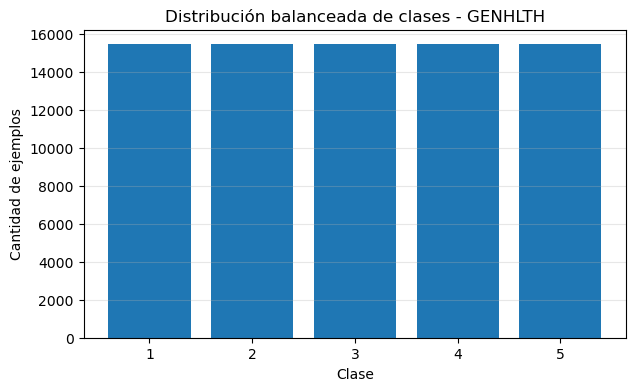

In [6]:
# Gráfica de distribución de clases balanceadas
conteo = df_balanceado[TARGET].value_counts().sort_index()
pyplot.figure(figsize=(7,4))
pyplot.bar(conteo.index.astype(str), conteo.values)
pyplot.title('Distribución balanceada de clases - GENHLTH')
pyplot.xlabel('Clase')
pyplot.ylabel('Cantidad de ejemplos')
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

## 6. División del dataset: 80% entrenamiento y 20% prueba

Los datos de prueba no participan en el entrenamiento. Esta separación permite validar si el modelo generaliza correctamente.

In [7]:
X = df_balanceado.drop(columns=[TARGET]).values
y_valores_originales = df_balanceado[TARGET].astype(int).values

# Mapeo de clases originales 1..5 a etiquetas internas 0..4, como en el cuadernillo guía
clases_originales = np.sort(np.unique(y_valores_originales))
clase_a_indice = {int(clase): int(indice) for indice, clase in enumerate(clases_originales)}
indice_a_clase = {int(indice): int(clase) for clase, indice in clase_a_indice.items()}
y = np.array([clase_a_indice[c] for c in y_valores_originales])

num_labels = len(clases_originales)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)
print('Número de clases:', num_labels)
print('Mapeo interno:', indice_a_clase)

X_train: (61828, 60)
X_test : (15457, 60)
y_train: (61828,)
y_test : (15457,)
Número de clases: 5
Mapeo interno: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5}


## 7. Normalización de características

La regresión logística mejora su entrenamiento cuando las variables están en escalas similares.

Se calcula la media y desviación estándar **solo con el conjunto de entrenamiento**, y luego se aplica la misma transformación al conjunto de prueba. Esto evita fuga de información.

In [8]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print('Media aproximada del entrenamiento normalizado:', np.round(X_train_norm.mean(), 4))
print('Desviación estándar aproximada:', np.round(X_train_norm.std(), 4))

Media aproximada del entrenamiento normalizado: 0.0
Desviación estándar aproximada: 1.0


## 8. Función sigmoide

Se mantiene la función del cuadernillo guía. La sigmoide transforma los valores lineales del modelo en probabilidades.

In [9]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

## 9. Función de costo de Regresión Logística Regularizada

Esta función conserva la estructura del cuadernillo guía. Calcula:

- El costo de la regresión logística.
- El gradiente para actualizar los parámetros theta.
- La regularización, sin regularizar el término independiente $\theta_0$.

In [10]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo y gradiente de la regresión logística regularizada.

    theta : parámetros del modelo
    X     : matriz de entrenamiento con columna de unos incluida
    y     : vector binario para una clase contra todas las demás
    lambda_: parámetro de regularización
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta))
    epsilon = 1e-9

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum((-y * np.log(h + epsilon)) - ((1 - y) * np.log(1 - h + epsilon)))
    J = J + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * X.T.dot(h - y)
    grad = grad + (lambda_ / m) * temp

    return J, grad

## 10. Entrenamiento One-vs-All

Se entrena un clasificador binario por cada clase. Cada clasificador aprende a separar una clase específica contra todas las demás.

La matriz `all_theta` almacena los parámetros finales de cada clasificador.

In [11]:
def oneVsAll(X, y, num_labels, lambda_, maxiter=80):
    """
    Entrena num_labels clasificadores de regresión logística.

    Devuelve:
    all_theta     : matriz con los parámetros theta aprendidos
    historial_costo: lista con el costo por iteración de cada clase
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    historial_costo = []

    # Agrega unos a la matriz X
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        costos_clase = []

        def callback(theta_actual):
            costo_actual, _ = lrCostFunction(theta_actual, X_bias, (y == c), lambda_)
            costos_clase.append(costo_actual)

        options = {'maxiter': maxiter}

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_bias, (y == c), lambda_),
            jac=True,
            method='L-BFGS-B',
            callback=callback,
            options=options
        )

        all_theta[c] = res.x
        historial_costo.append(costos_clase)
        print(f'Clase interna {c} entrenada. Costo final: {res.fun:.6f}')

    return all_theta, historial_costo

## 11. Entrenamiento del modelo

Se define el parámetro de regularización y se entrena el modelo con el conjunto de entrenamiento.

In [12]:
lambda_ = 0.1
all_theta, historial_costo = oneVsAll(X_train_norm, y_train, num_labels, lambda_, maxiter=80)
print('Dimensión de all_theta:', all_theta.shape)

Clase interna 0 entrenada. Costo final: 0.385868
Clase interna 1 entrenada. Costo final: 0.449029
Clase interna 2 entrenada. Costo final: 0.486998
Clase interna 3 entrenada. Costo final: 0.459053
Clase interna 4 entrenada. Costo final: 0.338451
Dimensión de all_theta: (5, 61)


## 12. Gráfica de costo

La gráfica permite observar cómo disminuye el costo durante el entrenamiento de los clasificadores One-vs-All.

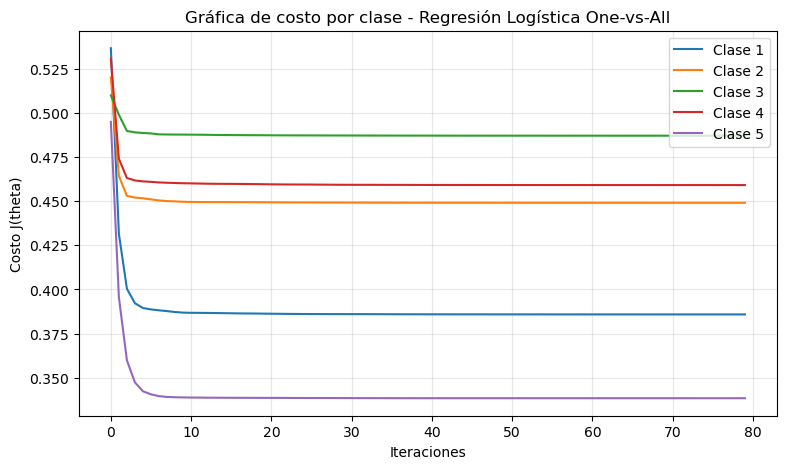

In [13]:
pyplot.figure(figsize=(9,5))

for i, costos in enumerate(historial_costo):
    if len(costos) > 0:
        pyplot.plot(costos, label=f'Clase {indice_a_clase[i]}')

pyplot.title('Gráfica de costo por clase - Regresión Logística One-vs-All')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.legend()
pyplot.grid(alpha=0.3)
pyplot.show()

## 13. Función de predicción One-vs-All

Se mantiene la misma lógica del cuadernillo guía: para cada ejemplo se calculan las probabilidades de pertenecer a cada clase y se elige la clase con mayor probabilidad.

In [14]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    """
    m = X.shape[0]

    # Agrega unos a la matriz X
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)

    probabilidades = sigmoid(X_bias.dot(all_theta.T))
    p = np.argmax(probabilidades, axis=1)

    return p

## 14. Precisión del modelo

Se calcula la precisión en entrenamiento y prueba. La precisión en prueba es la más importante porque mide el rendimiento con datos no utilizados durante el entrenamiento.

In [15]:
pred_train = predictOneVsAll(all_theta, X_train_norm)
pred_test = predictOneVsAll(all_theta, X_test_norm)

acc_train = accuracy_score(y_train, pred_train) * 100
acc_test = accuracy_score(y_test, pred_test) * 100

print('Precisión del conjunto de entrenamiento: {:.2f}%'.format(acc_train))
print('Precisión del conjunto de prueba       : {:.2f}%'.format(acc_test))

Precisión del conjunto de entrenamiento: 42.93%
Precisión del conjunto de prueba       : 42.51%


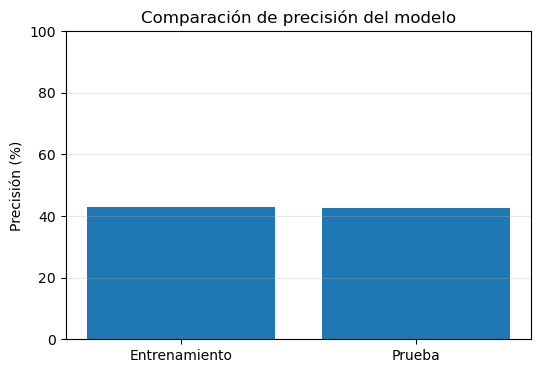

In [16]:
pyplot.figure(figsize=(6,4))
pyplot.bar(['Entrenamiento', 'Prueba'], [acc_train, acc_test])
pyplot.title('Comparación de precisión del modelo')
pyplot.ylabel('Precisión (%)')
pyplot.ylim(0, 100)
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

## 15. Matriz de confusión

La matriz de confusión muestra cuántos ejemplos fueron clasificados correctamente y cuántos fueron confundidos con otras clases.

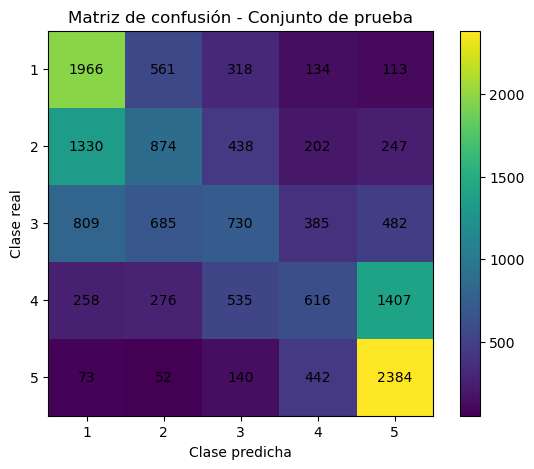

In [17]:
cm = confusion_matrix(y_test, pred_test)

pyplot.figure(figsize=(7,5))
pyplot.imshow(cm, interpolation='nearest')
pyplot.title('Matriz de confusión - Conjunto de prueba')
pyplot.colorbar()

tick_marks = np.arange(num_labels)
pyplot.xticks(tick_marks, [indice_a_clase[i] for i in range(num_labels)])
pyplot.yticks(tick_marks, [indice_a_clase[i] for i in range(num_labels)])
pyplot.xlabel('Clase predicha')
pyplot.ylabel('Clase real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pyplot.text(j, i, cm[i, j], ha='center', va='center')

pyplot.show()

## 16. Reporte de clasificación

El reporte muestra precisión, recall y F1-score por cada clase. Esto permite evaluar si el modelo clasifica de forma equilibrada todas las categorías.

In [ ]:
nombres_clases = [str(indice_a_clase[i]) for i in range(num_labels)]
print(classification_report(y_test, pred_test, target_names=nombres_clases))

## 17. Predicciones de ejemplo

Se toman ejemplos del conjunto de prueba para demostrar el funcionamiento del modelo. Se muestran la clase real y la clase predicha.

In [ ]:
cantidad_ejemplos = min(15, X_test_norm.shape[0])
indices = np.random.choice(X_test_norm.shape[0], cantidad_ejemplos, replace=False)

XPrueba = X_test_norm[indices, :]
y_real = y_test[indices]
y_pred = predictOneVsAll(all_theta, XPrueba)

resultado_predicciones = pd.DataFrame({
    'Clase real interna': y_real,
    'Clase predicha interna': y_pred,
    'GENHLTH real': [indice_a_clase[i] for i in y_real],
    'GENHLTH predicho': [indice_a_clase[i] for i in y_pred]
})

resultado_predicciones

## 18. Interpretación de resultados

El modelo entrenado con regresión logística multiclase One-vs-All permite clasificar el estado general de salud reportado en la encuesta BRFSS 2020.

El preprocesamiento se realizó con Pandas, eliminando valores faltantes, seleccionando variables numéricas, normalizando características y balanceando las clases para evitar que el modelo favorezca a la clase con más ejemplos.

La división 80/20 garantiza que el conjunto de prueba no sea utilizado durante el entrenamiento. Las gráficas de costo, precisión y la matriz de confusión permiten observar la efectividad del modelo.

**Conclusión:** Si la precisión de prueba es cercana a la precisión de entrenamiento, el modelo generaliza de forma aceptable. Si la precisión de entrenamiento es mucho mayor que la de prueba, puede existir sobreajuste.